In [ ]:
import pandas as pd
df=pd.read_csv("netflix_customer_churn.csv")
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [ ]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [ ]:
df.shape

(5000, 14)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0


In [ ]:
df.dtypes

,0
customer_id,object
age,int64
gender,object
subscription_type,object
watch_hours,float64
last_login_days,int64
region,object
device,object
monthly_fee,float64
churned,int64


/tmp/ipykernel_604/1873632518.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['Not Churned', 'Churned'])


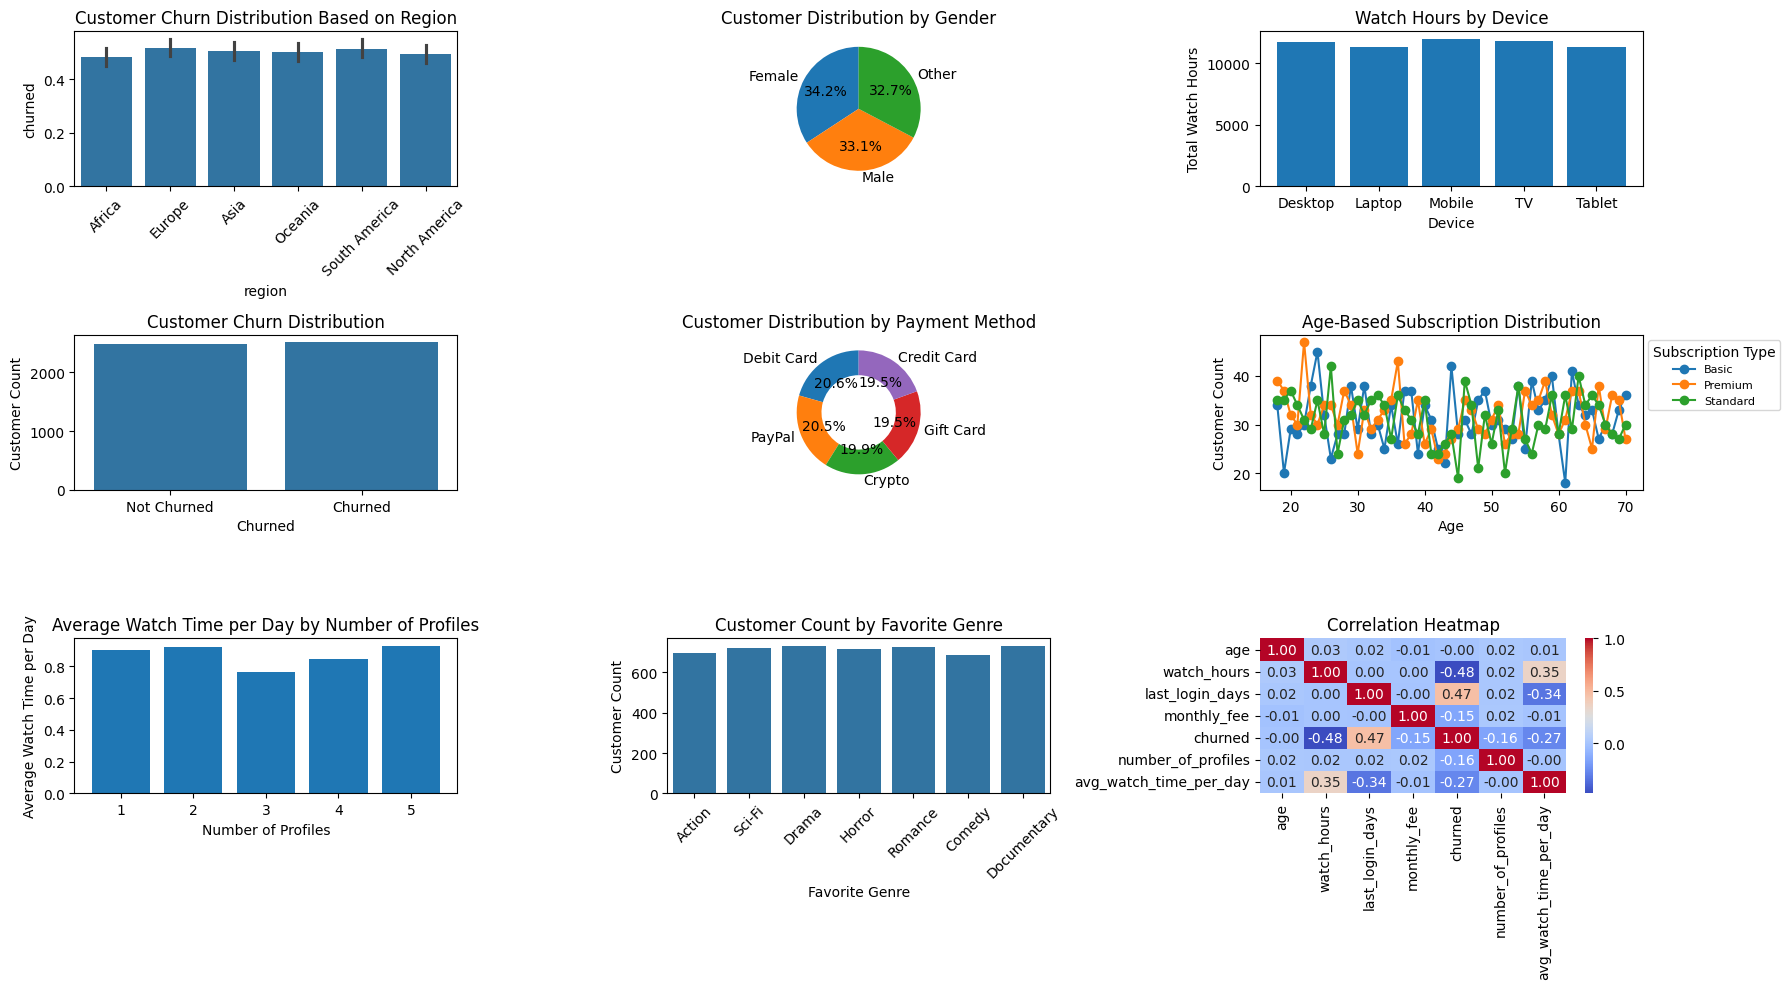

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(18, 10))

# 1. Churn Analysis Based Region
sns.barplot(data=df, x='region',y='churned', ax=axes[0, 0])
axes[0, 0].set_title('Customer Churn Distribution Based on Region')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Gender Distribution
gender_count = df['gender'].value_counts()

axes[0, 1].pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=90
)

axes[0, 1].set_title('Customer Distribution by Gender')

# 3. Water Hours Distribution based on watch_hours
device_watch = df.groupby('device')['watch_hours'].sum()

axes[0, 2].bar(
    device_watch.index,
    device_watch.values
)

axes[0, 2].set_title('Watch Hours by Device')
axes[0, 2].set_xlabel('Device')
axes[0, 2].set_ylabel('Total Watch Hours')
# 4. Churned or not churned distribution

sns.countplot(data=df, x='churned', ax=axes[1,0])

axes[1,0].set_title('Customer Churn Distribution')
axes[1,0].set_xlabel('Churned')
axes[1,0].set_ylabel('Customer Count')
axes[1,0].set_xticklabels(['Not Churned', 'Churned'])
# 5. Payment_type Distribution
payment_count = df['payment_method'].value_counts()

axes[1, 1].pie(
    payment_count,
    labels=payment_count.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

axes[1, 1].set_title('Customer Distribution by Payment Method')
# 6. Age Based Subscription_type
age_subscription = df.groupby(
    ['age', 'subscription_type']
).size().unstack(fill_value=0)

age_subscription.plot(
    kind='line',
    marker='o',
    ax=axes[1, 2]
)

axes[1, 2].set_title('Age-Based Subscription Distribution')
axes[1, 2].set_xlabel('Age')
axes[1, 2].set_ylabel('Customer Count')

axes[1, 2].legend(
    title='Subscription Type',
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fontsize=8
)
# 7. Profile Based Avg Watch time per day
profile_watch = df.groupby(
    'number_of_profiles'
)['avg_watch_time_per_day'].mean()

axes[2, 0].bar(
    profile_watch.index,
    profile_watch.values
)

axes[2,0].set_title('Average Watch Time per Day by Number of Profiles')
axes[2,0].set_xlabel('Number of Profiles')
axes[2,0].set_ylabel('Average Watch Time per Day')
# 8. Favourite Genre Distribution
sns.countplot(
    data=df,
    x='favorite_genre',
    ax=axes[2, 1]
)

axes[2, 1].set_title('Customer Count by Favorite Genre')
axes[2, 1].set_xlabel('Favorite Genre')
axes[2, 1].set_ylabel('Customer Count')
axes[2, 1].tick_params(axis='x', rotation=45)


correlation = df.select_dtypes(include='number').corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[2, 2]
)

axes[2, 2].set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()